In [77]:
import numpy as np
import torchaudio
import speechbrain as sb
import os
# Load the pretrained ECAPA-TDNN model for speaker verification
from speechbrain.inference import SpeakerRecognition
from sklearn.metrics import roc_curve



Load the model and report size and number of paramters

In [78]:
model_dir = "pretrained_models/spkrec-ecapa"
teacher_model = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir=model_dir)

size_in_MB = sum(os.path.getsize(os.path.join(model_dir, f)) for f in os.listdir(model_dir)) / (1024 * 1024)
print(f"Model size: {size_in_MB:.2f} MB")

# Print the model architecture
#print(model.modules)

# # Function to count the number of parameters
# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)

# # Get the number of trainable parameters in the model
# num_params = count_parameters(model.modules)
# print(f"Number of trainable parameters: {num_params:,}")


Model size: 84.86 MB


/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/speechbrain/utils/checkpoints.py:194: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

In [79]:
# Example: Load two audio files
signal1, fs1 = torchaudio.load('saby1.wav')
signal2, fs2 = torchaudio.load('saby2.wav')

Ensure that the audio files are compatible with the ECAPA-TDNN model's sample rate (usually 16 kHz). You may need to resample the audio

In [80]:
signal1 = torchaudio.transforms.Resample(orig_freq=fs1, new_freq=16000)(signal1)
signal2 = torchaudio.transforms.Resample(orig_freq=fs2, new_freq=16000)(signal2)


Perform Speaker Verification

In [81]:
# Perform speaker verification
score, prediction = teacher_model.verify_files('../AudioFiles/saby1.wav', '../AudioFiles/saby2.wav')

print(f'Speaker Verification Score: {score}')
print(f'Are they the same speaker? {"Yes" if prediction else "No"}')


Speaker Verification Score: tensor([0.4884])
Are they the same speaker? Yes


Visualise the Results

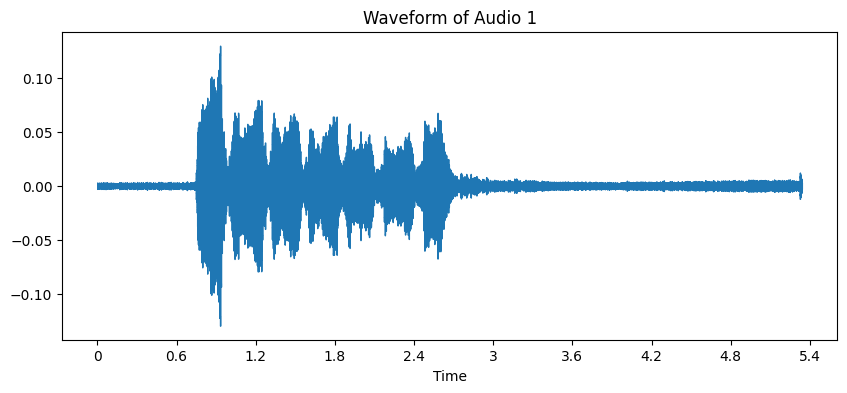

In [82]:
import matplotlib.pyplot as plt
import librosa.display

# Visualize the first audio file
plt.figure(figsize=(10, 4))
librosa.display.waveshow(signal1.numpy().squeeze(), sr=16000)
plt.title('Waveform of Audio 1')
plt.show()


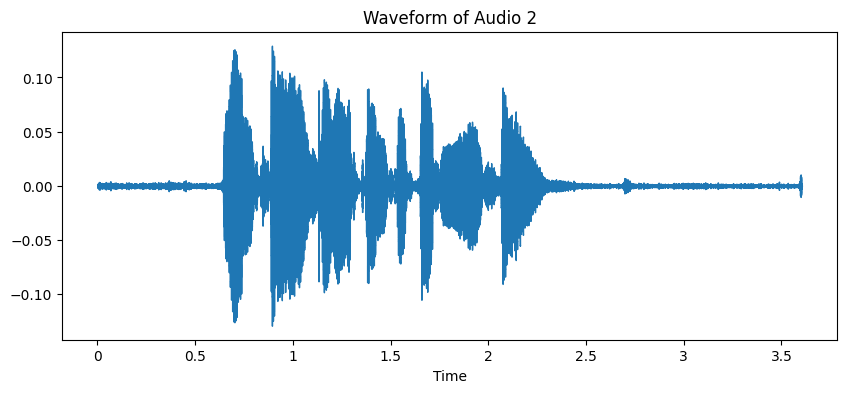

In [83]:
# Visualise 2nd Audio file
plt.figure(figsize=(10, 4))
librosa.display.waveshow(signal2.numpy().squeeze(), sr=16000)
plt.title('Waveform of Audio 2')
plt.show()

A smaller student model based on the architecture of the ECAPA-TDNN model. You can modify the number of layers or the size of each layer (e.g., reduce the number of TDNN blocks, lower the hidden dimension, etc.).

In [84]:
# Student Model 
import torch
import torch.nn as nn
import torch.nn.functional as F

class SmallECAPA_TDNN(nn.Module):
    def __init__(self):
        super(SmallECAPA_TDNN, self).__init__()
        # Define a smaller version of the ECAPA-TDNN
        self.tdnn1 = nn.Conv1d(80, 128, kernel_size=5, padding=2)
        self.tdnn2 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.fc = nn.Linear(128, 512)  # Smaller number of neurons

    def forward(self, x):
        x = F.relu(self.tdnn1(x))
        x = F.relu(self.tdnn2(x))
        x = torch.mean(x, dim=2)  # Simple pooling
        x = self.fc(x)
        return x

student_model = SmallECAPA_TDNN()


In [85]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [86]:
# Load the fine-tuned model
from speechbrain.pretrained import EncoderClassifier

import numpy as np
import torchaudio
import speechbrain as sb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from speechbrain.inference import SpeakerRecognition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram, GriffinLim
import os
import torchaudio
import torch
from sklearn.model_selection import train_test_split
from speechbrain.pretrained import EncoderClassifier
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as transforms

num_classes = 50


# Load the pre-trained ECAPA TDNN model
pretrained_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
pretrained_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)  # Adjusting output layer

# Load the fine-tuned model
fine_tuned_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
fine_tuned_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)
fine_tuned_classifier.load_state_dict(torch.load("fine_tuned_ecapa_tdnn_50.pth"))

# # Load the student model
# student_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
# student_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)
# student_classifier.load_state_dict(torch.load("student_model.pth"))

/var/folders/2d/mf93wtk914vbrkclc8d3hrt40000gn/T/ipykernel_24536/823468335.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fine_tuned_classifier.load_state_dict(torch.l

<All keys matched successfully>

In [87]:
# Custom dataset class
class DigitUtterDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.audio_paths = []
        self.labels = []
        self._prepare_data()

    def _prepare_data(self):
        # Assuming directory structure is `data_dir/speaker_id/session_x/audio.wav`
        speakers = sorted(os.listdir(self.data_dir))  # Sort speakers to assign consistent indices
        print(speakers)
        speakers.remove('.DS_Store')
        # Step 2: Create a mapping from speaker names to integer indices
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}
        # Optional: If you need just the indices in a set
        speakers_mod = set(speaker_to_index.values())
        #print(speakers_mod)
        
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}  # Map to indices
    
        for speaker in speakers:
            speaker_path = os.path.join(dataset_path, speaker)
            #print("Speaker Path",speaker_path)
            if os.path.isdir(speaker_path):
                for session in ['A', 'B', 'C', 'D']:  # Iterate over sessions
                    session_path = os.path.join(speaker_path, f"{speaker}{session}")
                    #print("Session Path", session_path)
                    if os.path.isdir(session_path):
                        #print(session_path)
                        for audio_file in os.listdir(session_path):
                            #print("Audio File Path ", audio_file)
                            # Check if the file is a .wav file
                            if audio_file.endswith('.wav'):
                                audio_path = os.path.join(session_path, audio_file)
                                self.audio_paths.append(audio_path)
                                #print(speaker_to_index[speaker])
                                self.labels.append(speaker_to_index[speaker])  # Use speaker ID as label 
                            else:
                                print("Not wave file")
                            # Check for duplicates
                                # if audio_path not in unique_samples:
                                #     unique_samples.add(audio_path)
                                #     self.audio_paths.append(audio_path)
                                #     self.labels.append(speaker)
                                # else:
                                #     print(f"Duplicate found: {audio_path}")
                    else:
                        print("This is not directory ->", session_path)   
    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = int(self.labels[idx])
        #print(f"Loading sample {idx}: {audio_path}, label: {label}")  # Debug statement

        audio, sample_rate = torchaudio.load(audio_path)  # Load audio file
        if self.transform:
            audio = self.transform(audio)
        return audio.squeeze(0), label  # Remove unnecessary channel dimension

    
# Custom collate function for padding
def collate_fn(batch):
    # Separate the batch into audio tensors and labels
    audios, labels = zip(*batch)

   # Calculate original lengths before padding
    lengths = torch.tensor([audio.shape[0] for audio in audios])

    # Pad all audio tensors to the length of the longest audio in the batch
    padded_audios = pad_sequence(audios, batch_first=True)  # Pads to [batch_size, max_len]

    labels = torch.tensor([int(label) for label in labels])

    return padded_audios, labels, lengths


In [88]:
dataset_path = 'DigitUtter-IITDH-dataset-master'

In [89]:
# Prepare the dataset
dataset = DigitUtterDataset(dataset_path)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)



['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']
Not wave file


In [90]:
print("Total Dataset " + str(len(dataset)))
print("Train Dataset " + str(len(train_dataset)))
print("Test Dataset " + str(len(test_dataset)))
print("Train Loader " + str(len(train_loader)))
print("Test Loader " + str(len(test_loader)))

Total Dataset 1998
Train Dataset 1598
Test Dataset 400
Train Loader 100
Test Loader 25


In [91]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

def get_logits_and_labels(model, data_loader):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            audio, labels, lengths = batch
            embeddings = model.encode_batch(audio)
            logits = model.mods.classifier(embeddings)
            logits = logits.squeeze(1)  # Remove extra dimension
            
            all_logits.append(logits)
            all_labels.append(labels)

    return torch.cat(all_logits), torch.cat(all_labels)

# Get logits for both models
pretrained_logits, pretrained_labels = get_logits_and_labels(pretrained_classifier, test_loader)
fine_tuned_logits, fine_tuned_labels = get_logits_and_labels(fine_tuned_classifier, test_loader)
#student_tuned_logits, student_tuned_labels =  get_logits_and_labels(student_classifier, test_loader)

In [92]:
print(pretrained_logits.shape)
print(fine_tuned_logits.shape)

torch.Size([400, 50])
torch.Size([400, 50])


In [93]:
pretrained_labels

tensor([11, 23,  2, 29, 35, 31, 49, 18, 23, 13, 22, 35, 17,  2, 21, 46, 26, 37,
        46, 20,  7,  3,  8, 13, 20, 36, 35, 18, 20, 14, 36,  6, 18, 43, 20, 10,
        14, 28, 31, 42,  6, 45, 26, 13,  0, 32, 26, 22, 40, 40, 36, 25, 39, 47,
        39, 24,  8, 40, 15, 48, 28, 17, 23, 27, 41, 19, 31, 37, 32, 21, 28, 24,
        26,  3, 16, 21,  6,  1, 11,  1, 41, 32, 45, 40,  5, 14,  5, 37,  9,  3,
        12, 14, 49, 17, 11, 41, 46,  5, 24, 31, 40, 45,  2, 43, 21, 21, 40, 10,
        33,  2, 15, 18, 40, 38,  8,  4, 46, 42, 13, 27, 27, 38, 34, 24,  7,  4,
        21,  4, 41, 47, 23, 21, 44, 19, 18, 37, 38, 22, 39, 27, 19, 47,  0, 20,
        42, 12, 15, 39, 42, 40, 12, 15,  0, 34,  7,  6, 48, 23, 45, 47, 48,  2,
        47, 43, 35, 49, 40,  7, 45,  5, 45, 49,  1, 13, 37,  9, 42, 46,  9,  0,
        17, 49, 28, 27, 34,  3, 10,  0, 23, 36, 12,  1, 35, 13, 29, 33,  1, 29,
         1, 28, 39, 15, 30, 31,  8,  2, 34, 11, 18,  2,  2, 12,  4, 15, 31,  6,
        34, 19, 12, 26,  0, 20, 33, 34, 

In [94]:
print(len(pretrained_labels))
print(len(pretrained_logits))

400
400


In [112]:
def calculate_eer_from_embeddings(embeddings, labels):
    print(embeddings.shape)
    print("Compare 1" + str(embeddings.unsqueeze(1).shape))
    print("Compare 2" + str(embeddings.unsqueeze(0).shape))
    # Calculate pairwise cosine similarities between embeddings
    similarity_score = F.cosine_similarity(embeddings.unsqueeze(1), embeddings.unsqueeze(0), dim=2).cpu().numpy()
    print("Similarity Score" + str(similarity_score.shape))
    # Create ground truth for speaker verification (1 if same speaker, 0 otherwise)
    true_labels = (labels.unsqueeze(1) == labels.unsqueeze(0)).float().cpu().numpy().flatten()
    similarity_score_flat = similarity_score.flatten()
    print(np.round(similarity_score_flat, 2))
    
    # Calculate FPR, TPR and threshold using ROC curve
    fpr,tpr,thresholds = roc_curve(true_labels, similarity_score_flat) 
    
    #Calculate EER
    eer_index = np.nanargmin(np.abs(fpr - (1 - tpr)))
    eer = fpr[eer_index]

    return eer, fpr, tpr, thresholds

# Get EER for both models
eer, fpr, tpr, thresholds = calculate_eer_from_embeddings(pretrained_logits, pretrained_labels)
eer_fine_tuned, fpr_fine_tuned, tpr_fine_tuned, thresholds_fine_tuned = calculate_eer_from_embeddings(fine_tuned_logits, fine_tuned_labels)
#eer_student, fpr_student, tpr_student, thresholds_student = calculate_eer_from_embeddings(student_tuned_logits, student_tuned_labels_labels)


torch.Size([400, 50])
Compare 1torch.Size([400, 1, 50])
Compare 2torch.Size([1, 400, 50])
Similarity Score(400, 400)
[1.   0.21 0.02 ... 0.07 0.29 1.  ]
torch.Size([400, 50])
Compare 1torch.Size([400, 1, 50])
Compare 2torch.Size([1, 400, 50])
Similarity Score(400, 400)
[ 1.   -0.    0.3  ... -0.12 -0.06  1.  ]


EER - PreTrained: 36.09%
EER - FineTuned: 19.99%


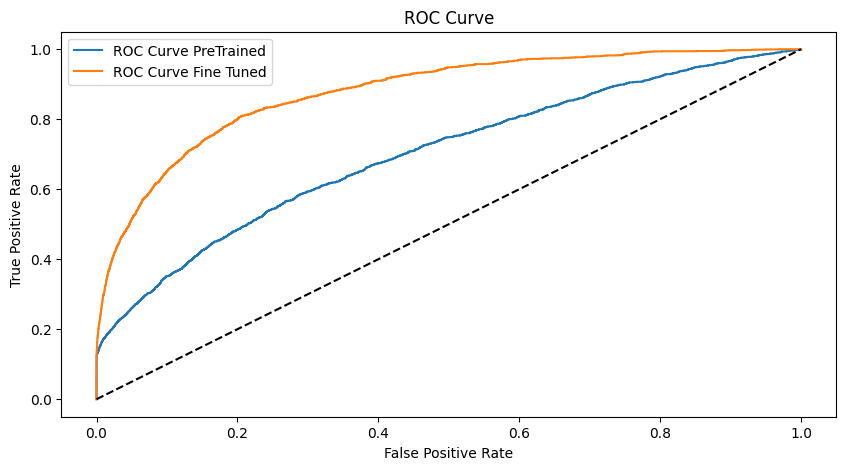

In [114]:
# Calculate EER

print(f"EER - PreTrained: {eer * 100:.2f}%")
print(f"EER - FineTuned: {eer_fine_tuned * 100:.2f}%")

# Plot ROC curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label='ROC Curve PreTrained')
plt.plot(fpr_fine_tuned, tpr_fine_tuned, label='ROC Curve Fine Tuned')
#plt.plot(fpr_student, tpr_student, label='ROC Student')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [115]:
# Accuracy Calculation
def calculate_accuracy_from_eer(eer):
    accuracy = 1 - eer
    return accuracy

print("Accuracy of Pre Trained Model ", calculate_accuracy_from_eer(eer))
print("Accuracy of Fine Tned Trained Model ", calculate_accuracy_from_eer(eer_fine_tuned))
#print("Accuracy of Student Model ", calculate_accuracy_from_eer(eer_student))

Accuracy of Pre Trained Model  0.6391423241074394
Accuracy of Fine Tned Trained Model  0.8001354494109228
